In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
models_to_plot = ["RNN-256", "GRU-256", "LSTM-256", "TRF-256"]

# Human Baseline Data 
human_data = [[1, 2, 3, 4], 
              [1.0, 0.94, 0.825, 0.68]]

In [3]:
def get_val(key, tag):
    try: return key.split(tag)[1].split("_")[0]
    except: return None

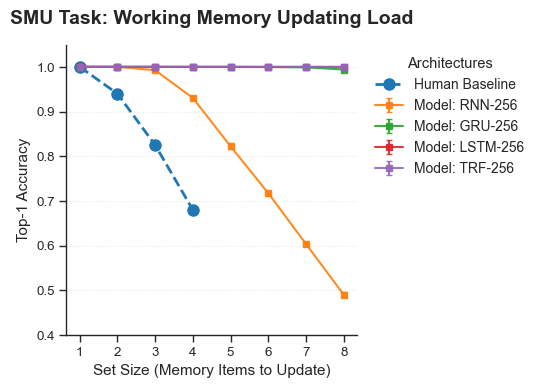

In [4]:
plt.rcParams["font.family"] = "Serif"
sns.set_context("paper", font_scale=1.1)
sns.set_style("ticks")

plot_data = {}

for m_name in models_to_plot:
    try:
        paths = [f"WM_Bench/{m_name}/output/test_acc_results.json", "test_acc_results.json"]
        results = None
        for p in paths:
            try:
                with open(p, "r") as f:
                    results = json.load(f)
                    break
            except FileNotFoundError: continue
        
        if results is None: continue

        m_smu = {}
        for key, val in results.items():
            # Filter for SMU Set Size keys while avoiding serial position details
            if "SMU_Task_set_size_" in key and "serial_position" not in key:
                ss = get_val(key, "set_size_")
                if ss is not None:
                    num_correct, num_total = val
                    acc = num_correct / num_total
                    # Binomial Standard Error
                    sem = np.sqrt((acc * (1 - acc)) / num_total)
                    m_smu[int(ss)] = (acc, sem)

        if m_smu:
            sorted_ss = sorted(m_smu.keys())
            accs = [m_smu[ss][0] for ss in sorted_ss]
            sems = [m_smu[ss][1] for ss in sorted_ss]
            plot_data[m_name] = (sorted_ss, accs, sems)
            
    except Exception as e:
        print(f"Error processing {m_name}: {e}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_box_aspect(1) # Square aspect ratio for academic plots

# Plot Human Baseline 
ax.plot(human_data[0], human_data[1], '--o',
        markersize=8, linewidth=2, label='Human Baseline', zorder=1)

# B. Plot Models
for m_name in models_to_plot:
    if m_name in plot_data:
        x, y, yerr = plot_data[m_name]
        ax.errorbar(x, y, yerr=yerr, label=f'Model: {m_name}', 
                    fmt='-s', markersize=4, linewidth=1.5, capsize=2, 
                    alpha=0.9, zorder=2)

ax.set_title("SMU Task: Working Memory Updating Load", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Set Size (Memory Items to Update)", fontsize=11)
ax.set_ylabel("Top-1 Accuracy", fontsize=11)

ax.set_xticks(range(1, 9))
ax.set_ylim([0.4, 1.05])
ax.grid(axis='y', linestyle=':', alpha=0.4)
sns.despine(ax=ax, trim=False)

ax.legend(title="Architectures", frameon=False, loc='upper left', 
          bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
# plt.savefig('smu_unified_benchmark.png', bbox_inches='tight', dpi=300)
plt.show()